In [1]:
import numpy as np

from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G0_muS
from superconductivity.api import NDArray64

from IPython import get_ipython

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic(
        "config", "InlineBackend.rc = {'figure.dpi': 300}"
    )  # choose a value you like

In [2]:
etchdata = np.genfromtxt(
    "/Users/oliver/Documents/cryolab/dissertation/methods/sample/rie/etchdata.csv",
    skip_header=1,
    delimiter=",",
)
start = 94000
stop = 180030
time = etchdata[start:stop, 0]
laser = etchdata[start:stop, 1]
time = (time - time[0]) / 60
# laser = laser / 100

# laser -= np.min(laser)
# laser /= np.max(laser)

In [3]:
time.shape

(86030,)

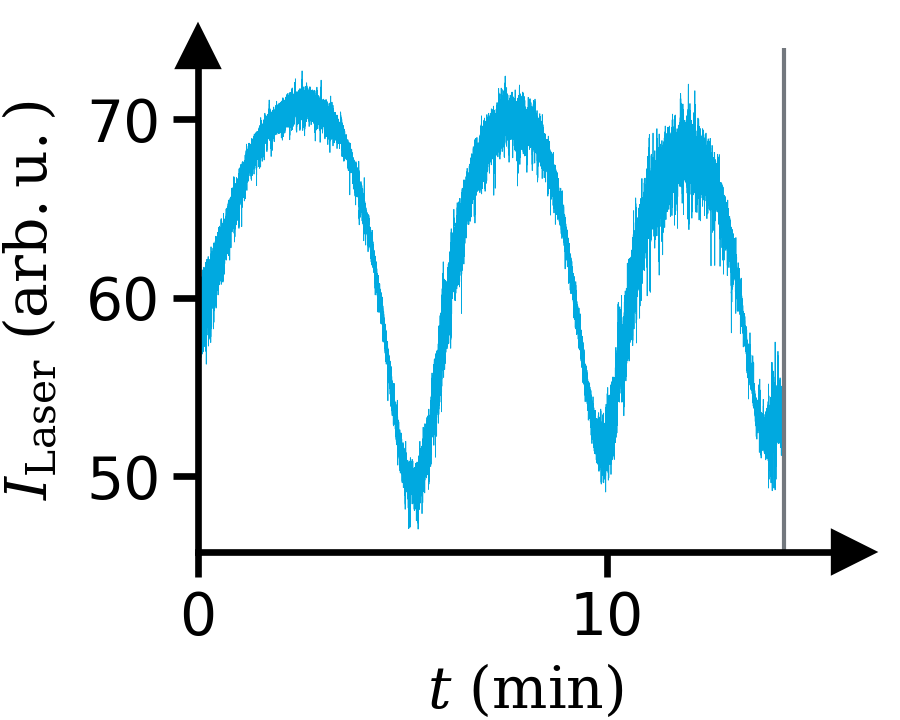

In [5]:
fig, ax = sc.get_figure(figsize=(1.5, 1.2), padding=(0.25, 0.2))

ax.plot(time, laser, "-", lw=0.1, ms=5, color=sc.seeblau100)
ylim = ax.get_ylim()
ax.vlines(time[-1], ymin=ylim[0], ymax=ylim[1], lw=0.5, color=sc.seegrau100)

ax.set_ylim(ylim)
ax.set_xlim(0, 16)

xlabel = r"$t\ (\mathrm{min})$"
ylabel = r"$I_\mathrm{Laser}\ (\mathrm{arb.u.})$"
title = "methods/sample/rie"

sc.theory_layout(
    fig,
    ax,
    title,
    xlabel,
    ylabel,
)